# Spotify Hybrid Recommendation Engine

Building a hybrid music recommender that fuses collaborative filtering (SVD), content-based cosine similarity, and a real-time session layer.

## Pipeline overview:
- Generate synthetic Spotify-like dataset (tracks with audio features + user interactions)
- Validate data and run EDA
- Preprocess: temporal train/val/test splits, sparse matrices, feature scaling
- Train collaborative filter (TruncatedSVD) and content-based model (cosine similarity)
- Fuse into weighted hybrid with cold-start handling
- Re-rank with diversity constraints
- Add real-time session personalization
- Evaluate with Precision, Recall, NDCG, MAP, Hit Rate @K

## Stack I'm using:
- pandas, numpy, scipy, scikit-learn
- matplotlib for plots
- joblib for serialization
- FastAPI + uvicorn for serving (separate `pipeline.py`)

In [1]:
!pip install -q pandas numpy scipy scikit-learn matplotlib joblib

In [2]:
import os
import json
import time
import logging
from pathlib import Path
from dataclasses import dataclass, asdict
from functools import wraps

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

%matplotlib inline

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("recommender")

### Configuration and Reproducibility

In [3]:
@dataclass
class RecConfig:
    # seed
    random_seed: int = 42
    top_k: int = 10

    # dataset
    n_users: int = 500
    n_tracks: int = 2000
    n_artists: int = 200
    n_genres: int = 15
    min_interactions: int = 10
    max_interactions: int = 80
    test_ratio: float = 0.2
    val_ratio: float = 0.1

    # model hparams
    svd_n_components: int = 50
    collab_weight: float = 0.6
    content_weight: float = 0.4

    # ranking
    popularity_weight: float = 0.05
    diversity_penalty: float = 0.1

    # paths
    data_dir: str = "./data"
    artifacts_dir: str = "./artifacts"

cfg = RecConfig()

AUDIO_FEATURES = [
    "danceability", "energy", "valence", "tempo",
    "acousticness", "instrumentalness", "loudness",
    "speechiness", "liveness",
]

GENRES = [
    "pop", "rock", "hip-hop", "r&b", "electronic", "jazz", "classical",
    "country", "latin", "indie", "metal", "folk", "blues", "reggae", "soul",
]

GENRE_FEATURE_PROFILES = {
    "pop":        {"danceability": 0.70, "energy": 0.65, "valence": 0.60, "tempo": 120, "acousticness": 0.15, "instrumentalness": 0.02, "loudness": -5.5, "speechiness": 0.05, "liveness": 0.12},
    "rock":       {"danceability": 0.50, "energy": 0.80, "valence": 0.45, "tempo": 130, "acousticness": 0.10, "instrumentalness": 0.05, "loudness": -4.5, "speechiness": 0.04, "liveness": 0.18},
    "hip-hop":    {"danceability": 0.78, "energy": 0.65, "valence": 0.50, "tempo": 100, "acousticness": 0.10, "instrumentalness": 0.01, "loudness": -6.0, "speechiness": 0.20, "liveness": 0.13},
    "r&b":        {"danceability": 0.68, "energy": 0.55, "valence": 0.55, "tempo": 105, "acousticness": 0.25, "instrumentalness": 0.02, "loudness": -7.0, "speechiness": 0.08, "liveness": 0.11},
    "electronic": {"danceability": 0.75, "energy": 0.80, "valence": 0.45, "tempo": 128, "acousticness": 0.05, "instrumentalness": 0.40, "loudness": -5.0, "speechiness": 0.06, "liveness": 0.15},
    "jazz":       {"danceability": 0.50, "energy": 0.40, "valence": 0.50, "tempo": 115, "acousticness": 0.60, "instrumentalness": 0.30, "loudness": -10.0, "speechiness": 0.04, "liveness": 0.20},
    "classical":  {"danceability": 0.25, "energy": 0.25, "valence": 0.35, "tempo": 100, "acousticness": 0.90, "instrumentalness": 0.85, "loudness": -18.0, "speechiness": 0.03, "liveness": 0.10},
    "country":    {"danceability": 0.55, "energy": 0.60, "valence": 0.65, "tempo": 125, "acousticness": 0.35, "instrumentalness": 0.02, "loudness": -6.5, "speechiness": 0.04, "liveness": 0.15},
    "latin":      {"danceability": 0.80, "energy": 0.70, "valence": 0.70, "tempo": 110, "acousticness": 0.20, "instrumentalness": 0.03, "loudness": -5.5, "speechiness": 0.07, "liveness": 0.14},
    "indie":      {"danceability": 0.55, "energy": 0.55, "valence": 0.50, "tempo": 118, "acousticness": 0.30, "instrumentalness": 0.10, "loudness": -8.0, "speechiness": 0.04, "liveness": 0.13},
    "metal":      {"danceability": 0.35, "energy": 0.92, "valence": 0.30, "tempo": 140, "acousticness": 0.02, "instrumentalness": 0.10, "loudness": -3.5, "speechiness": 0.06, "liveness": 0.20},
    "folk":       {"danceability": 0.45, "energy": 0.35, "valence": 0.55, "tempo": 110, "acousticness": 0.70, "instrumentalness": 0.05, "loudness": -11.0, "speechiness": 0.04, "liveness": 0.12},
    "blues":      {"danceability": 0.50, "energy": 0.50, "valence": 0.40, "tempo": 105, "acousticness": 0.50, "instrumentalness": 0.08, "loudness": -9.0, "speechiness": 0.04, "liveness": 0.18},
    "reggae":     {"danceability": 0.72, "energy": 0.55, "valence": 0.70, "tempo": 90, "acousticness": 0.30, "instrumentalness": 0.05, "loudness": -8.5, "speechiness": 0.05, "liveness": 0.14},
    "soul":       {"danceability": 0.62, "energy": 0.55, "valence": 0.60, "tempo": 108, "acousticness": 0.35, "instrumentalness": 0.03, "loudness": -7.5, "speechiness": 0.05, "liveness": 0.13},
}

for d in ["data/raw", "data/processed", "artifacts/models", "artifacts/metrics", "artifacts/figures"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(asdict(cfg))

{'random_seed': 42, 'top_k': 10, 'n_users': 500, 'n_tracks': 2000, 'n_artists': 200, 'n_genres': 15, 'min_interactions': 10, 'max_interactions': 80, 'test_ratio': 0.2, 'val_ratio': 0.1, 'svd_n_components': 50, 'collab_weight': 0.6, 'content_weight': 0.4, 'popularity_weight': 0.05, 'diversity_penalty': 0.1, 'data_dir': './data', 'artifacts_dir': './artifacts'}


In [4]:
def set_seed(seed=42):
    np.random.seed(seed)

set_seed(cfg.random_seed)

def save_artifact(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(obj, path)
    logger.info(f"Saved: {path}")

def load_artifact(path):
    return joblib.load(path)

def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(data, f, indent=2, default=str)

print(f"Seed set to {cfg.random_seed}")

Seed set to 42


### Data Generation

Synthetic dataset that mimics real Spotify distributions. Each genre has calibrated audio feature profiles, users get 1-3 preferred genres for collaborative signal, and interactions follow a power-law.

In [5]:
FIRST_NAMES = [
    "Liam", "Emma", "Noah", "Olivia", "James", "Ava", "Elijah", "Sophia", "Lucas",
    "Mia", "Mason", "Luna", "Ethan", "Aria", "Aiden", "Chloe", "Jack", "Zoe",
    "Leo", "Lily", "Ben", "Ella", "Sam", "Grace", "Alex", "Nora", "Ryan", "Riley",
    "Max", "Isla", "Jay", "Ivy", "Dan", "Ruby", "Tom", "Maya", "Kai", "Eva",
]


def generate_artist_names(rng, n):
    prefixes = ["The", "DJ", "MC", "Lil", "Big", "Young", "Old", "King", "Queen", ""]
    roots = [
        "Midnight", "Shadow", "Crystal", "Electric", "Velvet", "Golden", "Silver",
        "Neon", "Cosmic", "Arctic", "Solar", "Lunar", "Storm", "Thunder", "Echo",
        "Phoenix", "Ember", "Frost", "Wave", "Dream", "Vibe", "Pulse", "Rhythm",
        "Flow", "Sage", "Blaze", "Coral", "Onyx", "Pearl", "Raven",
    ]
    suffixes = ["Band", "Crew", "Sound", "Project", "Collective", "Beats", "Tones",
                "Orchestra", "Ensemble", "Trio", "Duo", "System", ""]
    names = set()
    while len(names) < n:
        p, r, s = rng.choice(prefixes), rng.choice(roots), rng.choice(suffixes)
        names.add(" ".join(x for x in [p, r, s] if x))
    return sorted(names)


def generate_track_names(rng, n):
    adjectives = [
        "Lost", "Broken", "Eternal", "Fading", "Rising", "Falling", "Burning",
        "Frozen", "Dancing", "Silent", "Wild", "Sweet", "Dark", "Bright", "Last",
        "First", "Deep", "High", "Low", "Slow", "Fast", "New", "Old", "True",
    ]
    nouns = [
        "Love", "Heart", "Night", "Day", "Dream", "Fire", "Rain", "Star", "Moon",
        "Sun", "Road", "River", "Ocean", "Sky", "City", "Home", "Soul", "Mind",
        "World", "Light", "Shadow", "Time", "Memory", "Hope", "Fear", "Joy",
    ]
    names = set()
    while len(names) < n:
        a, noun = rng.choice(adjectives), rng.choice(nouns)
        suffix = rng.choice(["", " (feat. " + rng.choice(FIRST_NAMES) + ")", " - Remix", " II", ""])
        names.add(f"{a} {noun}{suffix}")
    return sorted(names)


def clip(val, lo, hi):
    return max(lo, min(hi, val))


def generate_tracks(rng):
    artist_names = generate_artist_names(rng, cfg.n_artists)
    artist_ids = [f"artist_{i:04d}" for i in range(cfg.n_artists)]
    track_names = generate_track_names(rng, cfg.n_tracks)

    artist_genres = rng.choice(GENRES, size=cfg.n_artists)
    artist_weights = rng.pareto(a=1.5, size=cfg.n_artists) + 1
    artist_weights /= artist_weights.sum()
    track_artist_idx = rng.choice(cfg.n_artists, size=cfg.n_tracks, p=artist_weights)

    records = []
    for i in range(cfg.n_tracks):
        aidx = track_artist_idx[i]
        genre = artist_genres[aidx]
        p = GENRE_FEATURE_PROFILES[genre]
        records.append({
            "track_id": f"track_{i:05d}",
            "track_name": track_names[i],
            "artist_id": artist_ids[aidx],
            "artist_name": artist_names[aidx],
            "genre": genre,
            "popularity": clip(rng.beta(2, 5) * 100, 0, 100),
            "danceability": clip(rng.normal(p["danceability"], 0.12), 0, 1),
            "energy": clip(rng.normal(p["energy"], 0.12), 0, 1),
            "valence": clip(rng.normal(p["valence"], 0.15), 0, 1),
            "tempo": clip(rng.normal(p["tempo"], 20), 50, 220),
            "acousticness": clip(rng.normal(p["acousticness"], 0.15), 0, 1),
            "instrumentalness": clip(rng.beta(1.5, 8) if p["instrumentalness"] < 0.2 else rng.beta(3, 3), 0, 1),
            "loudness": clip(rng.normal(p["loudness"], 3.0), -30, 0),
            "speechiness": clip(rng.normal(p["speechiness"], 0.06), 0, 1),
            "liveness": clip(rng.normal(p["liveness"], 0.08), 0, 1),
            "duration_ms": int(np.clip(rng.normal(220_000, 50_000), 60_000, 600_000)),
            "release_year": int(rng.triangular(1990, 2023, 2025)),
        })
    return pd.DataFrame(records)


def generate_interactions(rng, tracks_df):
    track_ids = tracks_df["track_id"].values
    track_genres = tracks_df["genre"].values
    track_pop = tracks_df["popularity"].values / tracks_df["popularity"].sum()

    records = []
    base_ts = 1_700_000_000
    for u in range(cfg.n_users):
        user_id = f"user_{u:04d}"
        preferred = set(rng.choice(GENRES, size=rng.integers(1, 4), replace=False))
        genre_mask = np.array([g in preferred for g in track_genres], dtype=float)
        weights = genre_mask * 5.0 + track_pop * 100 + 0.1
        weights /= weights.sum()

        n_int = rng.integers(cfg.min_interactions, cfg.max_interactions + 1)
        chosen = rng.choice(len(track_ids), size=n_int, replace=False, p=weights)
        for idx in chosen:
            records.append({
                "user_id": user_id,
                "track_id": track_ids[idx],
                "play_count": min(int(rng.pareto(a=1.0) + 1), 50),
                "timestamp": base_ts + int(rng.integers(0, 30_000_000)),
            })
    return pd.DataFrame(records)


rng = np.random.default_rng(cfg.random_seed)

tracks_path = Path("data/raw/tracks.csv")
interactions_path = Path("data/raw/interactions.csv")

if tracks_path.exists() and interactions_path.exists():
    tracks_df = pd.read_csv(tracks_path)
    interactions_df = pd.read_csv(interactions_path)
    print("Loaded existing data from disk")
else:
    tracks_df = generate_tracks(rng)
    interactions_df = generate_interactions(rng, tracks_df)
    tracks_df.to_csv(tracks_path, index=False)
    interactions_df.to_csv(interactions_path, index=False)
    print(f"Generated: {len(tracks_df)} tracks, {len(interactions_df)} interactions")

print(f"Tracks: {tracks_df.shape}, Interactions: {interactions_df.shape}")

Generated: 2000 tracks, 22310 interactions
Tracks: (2000, 17), Interactions: (22310, 4)


In [6]:
print("=== Tracks sample ===")
print(tracks_df.head(3).to_string())
print(f"\nGenres: {tracks_df['genre'].nunique()}, Artists: {tracks_df['artist_id'].nunique()}")

print("\n=== Interactions sample ===")
print(interactions_df.head(3).to_string())

n_users = interactions_df["user_id"].nunique()
n_tracks = tracks_df["track_id"].nunique()
sparsity = 1.0 - len(interactions_df) / (n_users * n_tracks)
print(f"\nUsers: {n_users}, Tracks: {n_tracks}, Interactions: {len(interactions_df)}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.1f}%)")

# quick validation
assert not tracks_df["track_id"].duplicated().any(), "duplicate track_ids"
assert not tracks_df["track_id"].isna().any(), "null track_ids"
assert (interactions_df["play_count"] >= 1).all(), "play_count < 1"
orphans = set(interactions_df["track_id"]) - set(tracks_df["track_id"])
assert len(orphans) == 0, f"{len(orphans)} orphan tracks"
print("\nValidation passed")

=== Tracks sample ===
      track_id           track_name    artist_id         artist_name    genre  popularity  danceability    energy   valence       tempo  acousticness  instrumentalness  loudness  speechiness  liveness  duration_ms  release_year
0  track_00000          Bright City  artist_0197  Young Thunder Crew    indie   46.023051      0.725502  0.324770  0.582467  115.575704      0.145002          0.185985 -9.499374     0.035711  0.048755       298658          2016
1  track_00001  Bright City - Remix  artist_0018     Big Silver Crew  country   59.339527      0.480633  0.578605  0.758007  100.245484      0.456694          0.155580 -6.831266     0.000000  0.318799       143665          2013
2  track_00002           Bright Day  artist_0197  Young Thunder Crew    indie   33.015276      0.310504  0.490055  0.218908  133.608219      0.067915          0.023024 -6.289482     0.072267  0.112766       165264          2019

Genres: 15, Artists: 199

=== Interactions sample ===
     user_i

### Exploratory Data Analysis

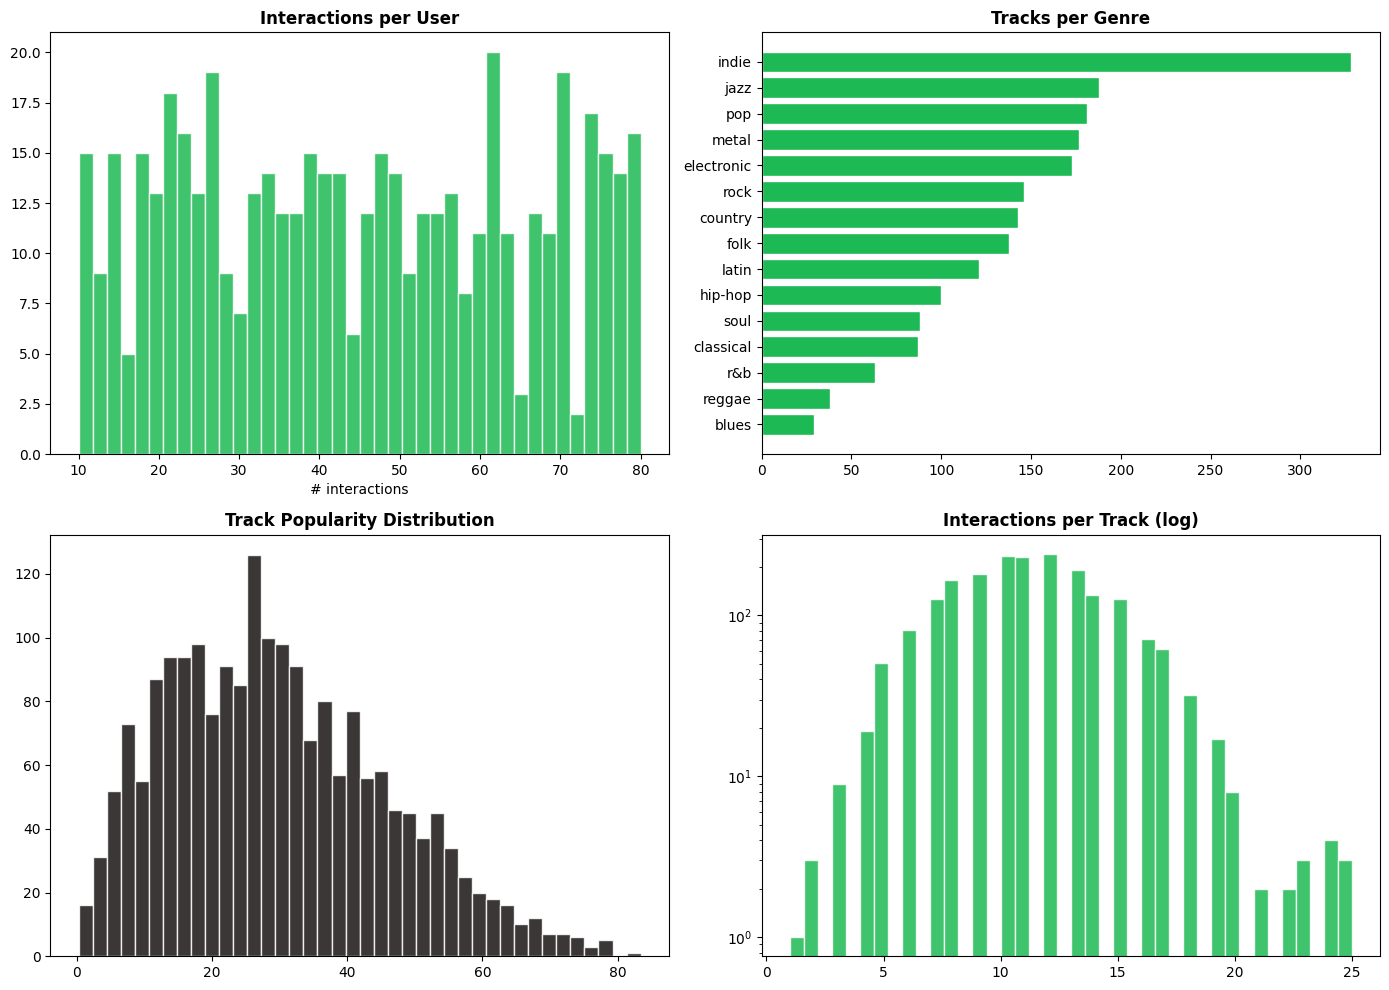

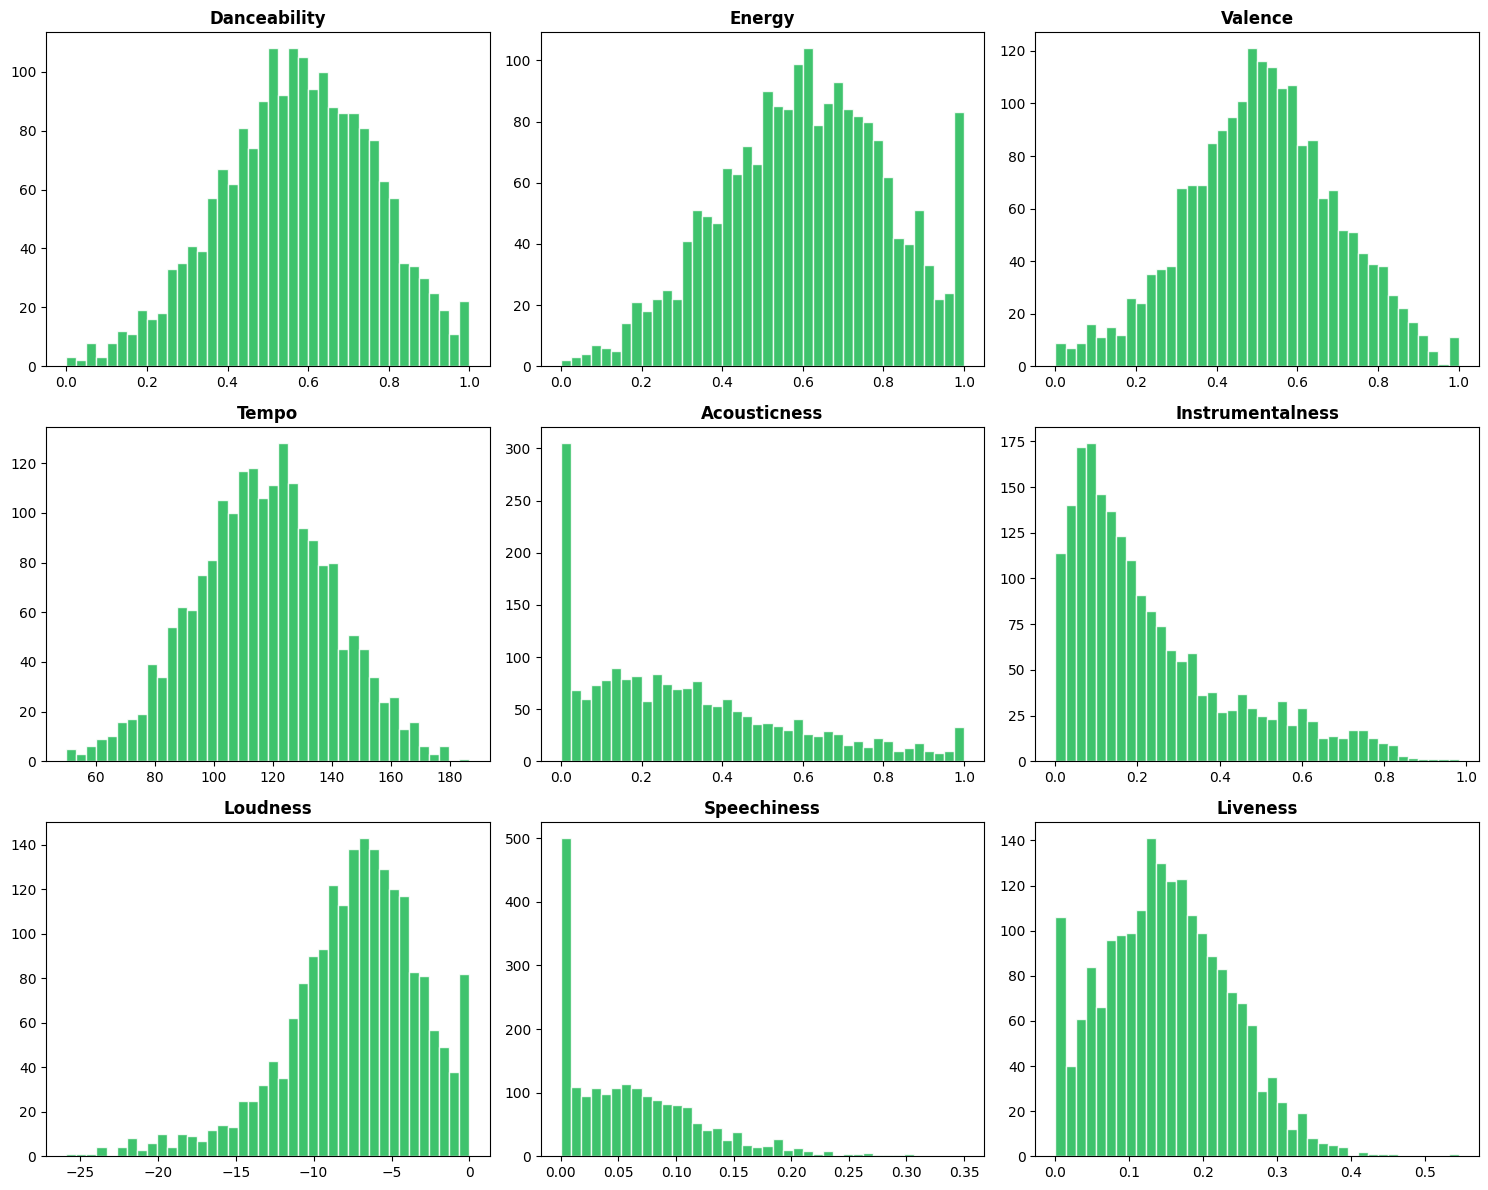

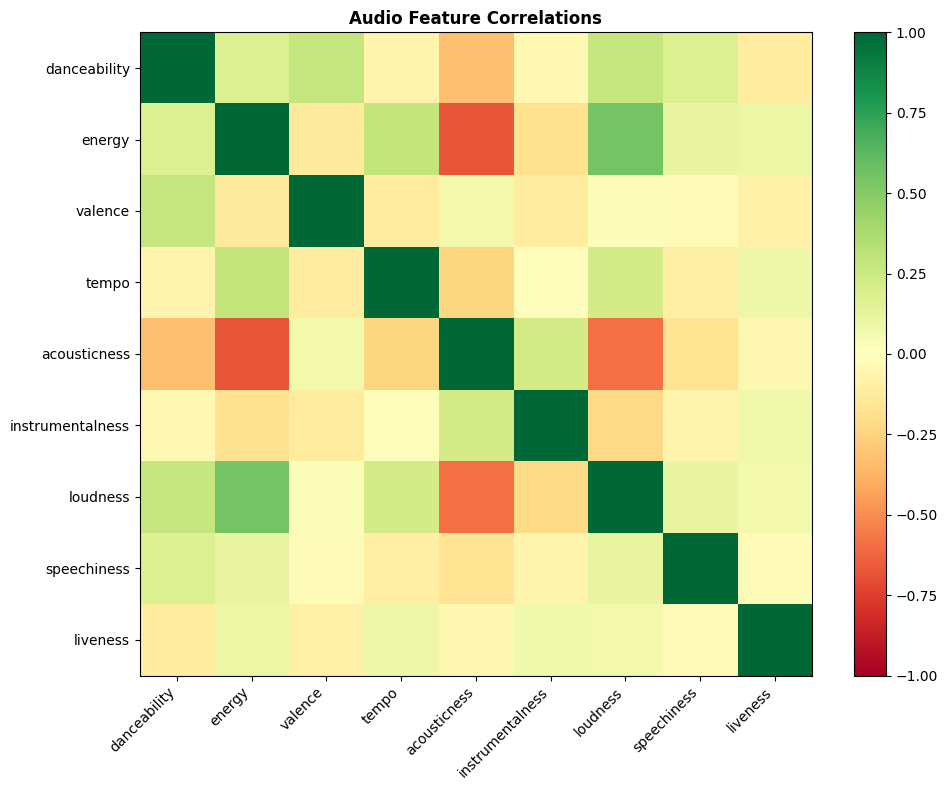

In [7]:
interactions_per_user = interactions_df.groupby("user_id").size()
interactions_per_track = interactions_df.groupby("track_id").size()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(interactions_per_user, bins=40, color="#1DB954", edgecolor="white", alpha=0.85)
axes[0, 0].set_title("Interactions per User", fontweight="bold")
axes[0, 0].set_xlabel("# interactions")

genre_counts = tracks_df["genre"].value_counts()
axes[0, 1].barh(genre_counts.index[:15], genre_counts.values[:15], color="#1DB954", edgecolor="white")
axes[0, 1].set_title("Tracks per Genre", fontweight="bold")
axes[0, 1].invert_yaxis()

axes[1, 0].hist(tracks_df["popularity"], bins=40, color="#191414", edgecolor="white", alpha=0.85)
axes[1, 0].set_title("Track Popularity Distribution", fontweight="bold")

axes[1, 1].hist(interactions_per_track, bins=40, color="#1DB954", edgecolor="white", alpha=0.85)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Interactions per Track (log)", fontweight="bold")

plt.tight_layout()
plt.savefig("artifacts/figures/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# audio feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(AUDIO_FEATURES):
    ax = axes[i // 3, i % 3]
    ax.hist(tracks_df[feat], bins=40, color="#1DB954", edgecolor="white", alpha=0.85)
    ax.set_title(feat.capitalize(), fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/figures/audio_features.png", dpi=150, bbox_inches="tight")
plt.show()

# correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = tracks_df[AUDIO_FEATURES].corr()
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(AUDIO_FEATURES)))
ax.set_yticks(range(len(AUDIO_FEATURES)))
ax.set_xticklabels(AUDIO_FEATURES, rotation=45, ha="right")
ax.set_yticklabels(AUDIO_FEATURES)
plt.colorbar(im, ax=ax)
ax.set_title("Audio Feature Correlations", fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/figures/feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### Preprocessing and Feature Engineering

In [8]:
# clean interactions
valid_track_ids = set(tracks_df["track_id"])
interactions_clean = interactions_df[interactions_df["track_id"].isin(valid_track_ids)].copy()
interactions_clean = interactions_clean.groupby(["user_id", "track_id"], as_index=False).agg(
    play_count=("play_count", "sum"),
    timestamp=("timestamp", "max"),
)
print(f"Cleaned interactions: {len(interactions_clean)}")

# temporal split per user
df_sorted = interactions_clean.sort_values("timestamp")
train_rows, val_rows, test_rows = [], [], []

for uid, group in df_sorted.groupby("user_id"):
    n = len(group)
    n_test = max(1, int(n * cfg.test_ratio))
    n_val = max(1, int(n * cfg.val_ratio))
    n_train = n - n_test - n_val
    if n_train < 1:
        train_rows.append(group)
        continue
    train_rows.append(group.iloc[:n_train])
    val_rows.append(group.iloc[n_train:n_train + n_val])
    test_rows.append(group.iloc[n_train + n_val:])

train_df = pd.concat(train_rows, ignore_index=True)
val_df = pd.concat(val_rows, ignore_index=True) if val_rows else pd.DataFrame(columns=df_sorted.columns)
test_df = pd.concat(test_rows, ignore_index=True) if test_rows else pd.DataFrame(columns=df_sorted.columns)
print(f"Split: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

# id mappings
users = sorted(interactions_clean["user_id"].unique())
tracks = sorted(interactions_clean["track_id"].unique())
user2idx = {u: i for i, u in enumerate(users)}
idx2user = {i: u for u, i in user2idx.items()}
track2idx = {t: i for i, t in enumerate(tracks)}
idx2track = {i: t for t, i in track2idx.items()}

# sparse interaction matrix (train only)
rows = train_df["user_id"].map(user2idx).values
cols = train_df["track_id"].map(track2idx).values
values = 1.0 + 0.5 * np.log1p(train_df["play_count"].values)
train_matrix = csr_matrix((values, (rows, cols)), shape=(len(user2idx), len(track2idx)))
print(f"Interaction matrix: {train_matrix.shape}, nnz={train_matrix.nnz}, density={train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]):.4f}")

# audio feature matrix
indexed = tracks_df.set_index("track_id").loc[
    [t for t, _ in sorted(track2idx.items(), key=lambda x: x[1])]
]
feature_matrix = indexed[AUDIO_FEATURES].values.astype(np.float64)
scaler = StandardScaler()
feature_matrix = scaler.fit_transform(feature_matrix)

# track popularity from training data
popularity = train_df.groupby("track_id")["play_count"].sum()
track_popularity = np.zeros(len(track2idx))
for tid, count in popularity.items():
    if tid in track2idx:
        track_popularity[track2idx[tid]] = count
if track_popularity.max() > 0:
    track_popularity /= track_popularity.max()

# user consumed sets
user_consumed_train = {}
for uid, group in train_df.groupby("user_id"):
    user_consumed_train[uid] = set(group["track_id"])

# save processed splits
train_df.to_csv("data/processed/train.csv", index=False)
val_df.to_csv("data/processed/val.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)
save_artifact(scaler, Path("data/processed/feature_scaler.joblib"))

print("Preprocessing done")

Cleaned interactions: 22310
Split: train=16038, val=2010, test=4262
Interaction matrix: (500, 2000), nnz=16038, density=0.0160
Preprocessing done


In [9]:
# genre TF-IDF features
ordered_tracks = sorted(track2idx.items(), key=lambda x: x[1])
genre_texts = []
for tid, _ in ordered_tracks:
    row = tracks_df[tracks_df["track_id"] == tid].iloc[0]
    genre_texts.append(row["genre"] + " " + row["artist_name"])

tfidf = TfidfVectorizer(max_features=100)
genre_features = tfidf.fit_transform(genre_texts).toarray()
print(f"Genre TF-IDF: {genre_features.shape}")

# combined features (audio 70% + genre 30%)
audio_norm = normalize(feature_matrix, norm="l2")
genre_norm = normalize(genre_features, norm="l2")
combined_features = normalize(np.hstack([audio_norm * 0.7, genre_norm * 0.3]), norm="l2")
print(f"Combined features: {combined_features.shape}")

# user profiles: weighted avg of consumed track features
user_ids_sorted = sorted(train_df["user_id"].unique())
user2uidx = {u: i for i, u in enumerate(user_ids_sorted)}
user_profiles = np.zeros((len(user_ids_sorted), combined_features.shape[1]))

for uid, group in train_df.groupby("user_id"):
    uidx = user2uidx[uid]
    vectors, weights = [], []
    timestamps = group["timestamp"].values
    ts_norm = (timestamps - timestamps.min()) / max(1, timestamps.max() - timestamps.min())
    for j, (_, row) in enumerate(group.iterrows()):
        if row["track_id"] in track2idx:
            tidx = track2idx[row["track_id"]]
            recency = 0.5 + 0.5 * (ts_norm[j] if j < len(ts_norm) else 1.0)
            weights.append(np.log1p(row["play_count"]) * recency)
            vectors.append(combined_features[tidx])
    if vectors:
        w = np.array(weights)
        w /= w.sum()
        user_profiles[uidx] = np.average(vectors, axis=0, weights=w)

print(f"User profiles: {user_profiles.shape}")

Genre TF-IDF: (2000, 66)
Combined features: (2000, 75)
User profiles: (500, 75)


### Collaborative Filtering (Truncated SVD)

Matrix factorization on the sparse user-item interaction matrix. Decomposes into latent user and item factors, recommendations via dot product in the latent space.

In [10]:
class CollaborativeFilter:
    def __init__(self, n_components=50):
        self.n_components = n_components
        self.svd = TruncatedSVD(n_components=n_components, random_state=cfg.random_seed)
        self.user_factors = None
        self.item_factors = None
        self.is_fitted = False

    def fit(self, interaction_matrix):
        self.user_factors = self.svd.fit_transform(interaction_matrix)
        self.item_factors = self.svd.components_.T
        self.user_factors = normalize(self.user_factors, norm="l2")
        self.item_factors = normalize(self.item_factors, norm="l2")
        explained = self.svd.explained_variance_ratio_.sum()
        print(f"SVD fitted: {interaction_matrix.shape}, explained variance: {explained:.4f}")
        self.is_fitted = True

    def predict_scores(self, user_idx):
        return self.user_factors[user_idx] @ self.item_factors.T

    def recommend(self, user_idx, n=10, exclude_indices=None):
        scores = self.predict_scores(user_idx)
        if exclude_indices:
            for idx in exclude_indices:
                scores[idx] = -np.inf
        top = np.argsort(scores)[::-1][:n]
        return [(int(i), float(scores[i])) for i in top]


collab = CollaborativeFilter(n_components=cfg.svd_n_components)
collab.fit(train_matrix)
save_artifact(collab, Path("artifacts/models/collaborative.joblib"))

# quick test
sample_uid = user2idx[users[0]]
sample_recs = collab.recommend(sample_uid, n=5)
print(f"\nSample collab recs for {users[0]}:")
for tidx, score in sample_recs:
    tid = idx2track[tidx]
    t = tracks_df[tracks_df["track_id"] == tid].iloc[0]
    print(f"  {t['track_name']} by {t['artist_name']} [{t['genre']}] score={score:.4f}")

SVD fitted: (500, 2000), explained variance: 0.2723

Sample collab recs for user_0000:
  Dancing Memory (feat. Ben) by Young Thunder Crew [indie] score=0.6070
  Sweet Dream by DJ Onyx Tones [r&b] score=0.6065
  Fading Joy (feat. Ivy) by Thunder System [r&b] score=0.6007
  Broken Dream II by The Midnight Collective [r&b] score=0.5935
  Eternal Hope II by Queen Shadow Tones [r&b] score=0.5814


### Content-Based Filtering

In [11]:
class ContentBasedFilter:
    def __init__(self):
        self.feature_matrix = None
        self.similarity_matrix = None
        self.user_profiles = None
        self.is_fitted = False

    def fit(self, feature_matrix, user_profiles=None):
        self.feature_matrix = normalize(feature_matrix, norm="l2")
        self.user_profiles = normalize(user_profiles, norm="l2") if user_profiles is not None else None
        if feature_matrix.shape[0] <= 10_000:
            self.similarity_matrix = cosine_similarity(self.feature_matrix)
        self.is_fitted = True
        print(f"Content model fitted: {feature_matrix.shape[0]} tracks, {feature_matrix.shape[1]} features")

    def similar_tracks(self, track_idx, n=10, exclude_indices=None):
        scores = self.similarity_matrix[track_idx].copy() if self.similarity_matrix is not None else \
            cosine_similarity(self.feature_matrix[track_idx:track_idx+1], self.feature_matrix)[0]
        scores[track_idx] = -np.inf
        if exclude_indices:
            for idx in exclude_indices:
                scores[idx] = -np.inf
        top = np.argsort(scores)[::-1][:n]
        return [(int(i), float(scores[i])) for i in top]

    def recommend_for_user(self, user_idx, n=10, exclude_indices=None):
        profile = self.user_profiles[user_idx:user_idx+1]
        scores = cosine_similarity(profile, self.feature_matrix)[0]
        if exclude_indices:
            for idx in exclude_indices:
                scores[idx] = -np.inf
        top = np.argsort(scores)[::-1][:n]
        return [(int(i), float(scores[i])) for i in top]

    def recommend_from_seeds(self, seed_indices, n=10, exclude_indices=None):
        seed_vecs = self.feature_matrix[seed_indices]
        profile = normalize(seed_vecs.mean(axis=0, keepdims=True), norm="l2")
        scores = cosine_similarity(profile, self.feature_matrix)[0]
        exclude = set(seed_indices)
        if exclude_indices:
            exclude |= exclude_indices
        for idx in exclude:
            scores[idx] = -np.inf
        top = np.argsort(scores)[::-1][:n]
        return [(int(i), float(scores[i])) for i in top]


content = ContentBasedFilter()
content.fit(combined_features, user_profiles)
save_artifact(content, Path("artifacts/models/content_based.joblib"))

Content model fitted: 2000 tracks, 75 features


In [12]:
# similar tracks test
sample_track = "track_00100"
sample_tidx = track2idx[sample_track]
similar = content.similar_tracks(sample_tidx, n=5)

t_info = tracks_df[tracks_df["track_id"] == sample_track].iloc[0]
print(f"Similar to: {t_info['track_name']} by {t_info['artist_name']} [{t_info['genre']}]\n")
for tidx, score in similar:
    tid = idx2track[tidx]
    t = tracks_df[tracks_df["track_id"] == tid].iloc[0]
    print(f"  {t['track_name']} by {t['artist_name']} [{t['genre']}] sim={score:.4f}")

Similar to: Broken Joy - Remix by Young Thunder Crew [indie]

  Dark Light - Remix by King Raven Ensemble [electronic] sim=0.7842
  Slow Mind - Remix by Phoenix Project [electronic] sim=0.7515
  Wild Sun - Remix by DJ Sage Collective [electronic] sim=0.7472
  Burning Joy II by The Vibe Sound [electronic] sim=0.7256
  Eternal Love by Young Thunder Crew [indie] sim=0.7226


### Hybrid Fusion, Ranking, and Real-time Session Layer

Weighted score fusion for warm users (60% collaborative, 40% content), content+popularity fallback for cold start, re-ranking with diversity constraints, and session-based profile adjustment for real-time updates.

In [13]:
def _normalize_scores(scores):
    if not scores:
        return {}
    vals = [s for _, s in scores]
    mn, mx = min(vals), max(vals)
    rng = mx - mn if mx > mn else 1.0
    return {idx: (score - mn) / rng for idx, score in scores}


class HybridRecommender:
    def __init__(self, collab_model, content_model, track_popularity,
                 collab_weight=0.6, content_weight=0.4, cold_threshold=5):
        self.collab = collab_model
        self.content = content_model
        self.track_popularity = track_popularity
        self.collab_weight = collab_weight
        self.content_weight = content_weight
        self.cold_threshold = cold_threshold

    def recommend(self, user_idx=None, n=10, exclude_indices=None,
                  n_consumed=0, seed_track_indices=None, mode="hybrid"):
        exclude = exclude_indices or set()
        candidate_n = n * 5

        is_cold = user_idx is None or n_consumed < self.cold_threshold

        if mode == "collaborative" and user_idx is not None:
            recs = self.collab.recommend(user_idx, n, exclude)
            return [(idx, score, "collaborative") for idx, score in recs]

        if mode == "content" and user_idx is not None:
            recs = self.content.recommend_for_user(user_idx, n, exclude)
            return [(idx, score, "content") for idx, score in recs]

        if mode == "popularity":
            return self._pop_recommend(n, exclude)

        if is_cold and seed_track_indices:
            content_recs = self.content.recommend_from_seeds(seed_track_indices, candidate_n, exclude)
            cs = _normalize_scores(content_recs)
            pop = {idx: self.track_popularity[idx] for idx in cs}
            blended = {idx: 0.8 * cs[idx] + 0.2 * pop.get(idx, 0) for idx in cs}
            return self._top_n(blended, n, "content+popularity")

        if is_cold:
            return self._pop_recommend(n, exclude)

        collab_recs = self.collab.recommend(user_idx, candidate_n, exclude)
        content_recs = self.content.recommend_for_user(user_idx, candidate_n, exclude)
        cs_collab = _normalize_scores(collab_recs)
        cs_content = _normalize_scores(content_recs)

        all_cands = set(cs_collab.keys()) | set(cs_content.keys())
        blended = {}
        for idx in all_cands:
            blended[idx] = self.collab_weight * cs_collab.get(idx, 0) + self.content_weight * cs_content.get(idx, 0)
        return self._top_n(blended, n, "hybrid")

    def _pop_recommend(self, n, exclude):
        scores = self.track_popularity.copy()
        for idx in exclude:
            scores[idx] = -np.inf
        top = np.argsort(scores)[::-1][:n]
        return [(int(i), float(scores[i]), "popularity") for i in top]

    def _top_n(self, scores, n, source):
        sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
        return [(idx, score, source) for idx, score in sorted_items]


def rerank(candidates, tracks_df, idx2track, track_popularity, n=10,
           diversity_weight=0.1, popularity_weight=0.05, max_per_artist=3):
    if not candidates:
        return []

    track_lookup = tracks_df.set_index("track_id")
    scored = []
    for idx, base_score, source in candidates:
        tid = idx2track.get(idx)
        if tid is None or tid not in track_lookup.index:
            continue
        t = track_lookup.loc[tid]
        pop = track_popularity[idx] if idx < len(track_popularity) else 0
        novelty = 1.0 - pop
        adjusted = base_score + popularity_weight * pop + 0.05 * novelty
        scored.append({
            "idx": idx, "track_id": tid,
            "artist_id": t.get("artist_id", ""), "genre": t.get("genre", ""),
            "adjusted_score": adjusted, "source": source,
        })

    scored.sort(key=lambda x: x["adjusted_score"], reverse=True)

    selected = []
    artist_counts, genre_counts = {}, {}
    for item in scored:
        if len(selected) >= n:
            break
        artist = item["artist_id"]
        if artist_counts.get(artist, 0) >= max_per_artist:
            continue
        genre = item["genre"]
        genre_penalty = diversity_weight * genre_counts.get(genre, 0) / max(1, len(selected))
        item["final_score"] = item["adjusted_score"] - genre_penalty
        selected.append(item)
        artist_counts[artist] = artist_counts.get(artist, 0) + 1
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

    selected.sort(key=lambda x: x["final_score"], reverse=True)
    return [(item["idx"], item["final_score"], item["source"]) for item in selected]


class RealtimeRecommender:
    def __init__(self, hybrid, content, feature_matrix, recency_boost=0.3):
        self.hybrid = hybrid
        self.content = content
        self.feature_matrix = feature_matrix
        self.recency_boost = recency_boost
        self.session_buffer = {}

    def record_interaction(self, user_idx, track_idx, timestamp=0.0):
        if user_idx not in self.session_buffer:
            self.session_buffer[user_idx] = []
        self.session_buffer[user_idx].append((track_idx, timestamp))

    def recommend_with_session(self, user_idx, n=10, exclude_indices=None, n_consumed=0):
        exclude = set(exclude_indices or set())
        if user_idx in self.session_buffer:
            for tidx, _ in self.session_buffer[user_idx]:
                exclude.add(tidx)

        session = self.session_buffer.get(user_idx, [])
        if not session:
            return self.hybrid.recommend(user_idx=user_idx, n=n, exclude_indices=exclude, n_consumed=n_consumed)

        # session-adjusted content profile
        weights = np.array([2.0 ** i for i in range(len(session))], dtype=np.float64)
        weights /= weights.sum()
        recent_vecs = np.array([self.feature_matrix[tidx] for tidx, _ in session])
        recent_profile = np.average(recent_vecs, axis=0, weights=weights)

        if self.content.user_profiles is not None and user_idx < len(self.content.user_profiles):
            original = self.content.user_profiles[user_idx]
            blended = (1 - self.recency_boost) * original + self.recency_boost * recent_profile
        else:
            blended = recent_profile

        blended = normalize(blended.reshape(1, -1), norm="l2")
        content_scores = cosine_similarity(blended, self.content.feature_matrix)[0]

        if self.hybrid.collab.is_fitted and user_idx < self.hybrid.collab.user_factors.shape[0]:
            collab_scores = self.hybrid.collab.predict_scores(user_idx)
            c_min, c_max = collab_scores.min(), collab_scores.max()
            if c_max > c_min:
                collab_scores = (collab_scores - c_min) / (c_max - c_min)
        else:
            collab_scores = np.zeros(len(content_scores))

        ct_min, ct_max = content_scores.min(), content_scores.max()
        if ct_max > ct_min:
            content_scores = (content_scores - ct_min) / (ct_max - ct_min)

        combined = self.hybrid.collab_weight * collab_scores + self.hybrid.content_weight * content_scores
        for idx in exclude:
            combined[idx] = -np.inf

        top = np.argsort(combined)[::-1][:n]
        return [(int(i), float(combined[i]), "realtime_hybrid") for i in top]


hybrid = HybridRecommender(
    collab_model=collab, content_model=content,
    track_popularity=track_popularity,
    collab_weight=cfg.collab_weight, content_weight=cfg.content_weight,
)

realtime = RealtimeRecommender(
    hybrid=hybrid, content=content, feature_matrix=combined_features,
)

print("Hybrid + ranking + realtime ready")

Hybrid + ranking + realtime ready


In [14]:
# hybrid recommendations for sample user
sample_user = users[0]
sample_uidx = user2idx[sample_user]
consumed = user_consumed_train.get(sample_user, set())
exclude = {track2idx[t] for t in consumed if t in track2idx}

candidates = hybrid.recommend(sample_uidx, n=15, exclude_indices=exclude, n_consumed=len(consumed))
ranked = rerank(candidates, tracks_df, idx2track, track_popularity, n=5)

print(f"Recs for {sample_user}:")
for idx, score, source in ranked:
    tid = idx2track[idx]
    t = tracks_df[tracks_df["track_id"] == tid].iloc[0]
    print(f"  {t['track_name']} by {t['artist_name']} [{t['genre']}] score={score:.4f} ({source})")

# simulate listening to a track and see recs update
play_track = list(track2idx.keys())[100]
realtime.record_interaction(sample_uidx, track2idx[play_track])
rt_candidates = realtime.recommend_with_session(sample_uidx, n=15, exclude_indices=exclude, n_consumed=len(consumed))
rt_ranked = rerank(rt_candidates, tracks_df, idx2track, track_popularity, n=5)

play_name = tracks_df[tracks_df["track_id"] == play_track].iloc[0]["track_name"]
print(f"\nAfter listening to {play_name}:")
for idx, score, source in rt_ranked:
    tid = idx2track[idx]
    t = tracks_df[tracks_df["track_id"] == tid].iloc[0]
    print(f"  {t['track_name']} by {t['artist_name']} [{t['genre']}] score={score:.4f} ({source})")

Recs for user_0000:
  Dancing Memory (feat. Ben) by Young Thunder Crew [indie] score=0.6500 (hybrid)
  Broken Dream II by The Midnight Collective [r&b] score=0.6241 (hybrid)
  Slow Dream by Thunder System [r&b] score=0.5725 (hybrid)
  Eternal Hope II by Queen Shadow Tones [r&b] score=0.5342 (hybrid)
  Low Joy (feat. Ethan) by Storm Crew [r&b] score=0.4939 (hybrid)

After listening to Broken Joy - Remix:
  Slow Dream by Thunder System [r&b] score=0.9402 (realtime_hybrid)
  Dancing Memory (feat. Ben) by Young Thunder Crew [indie] score=0.8998 (realtime_hybrid)
  New Fear - Remix by DJ Onyx Tones [r&b] score=0.8361 (realtime_hybrid)
  Wild Heart by Queen Blaze Duo [r&b] score=0.8188 (realtime_hybrid)
  True Hope II by Rhythm Collective [r&b] score=0.8172 (realtime_hybrid)


### Offline Evaluation

In [15]:
def precision_at_k(recommended, relevant, k):
    hits = sum(1 for r in recommended[:k] if r in relevant)
    return hits / k if k else 0.0

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    hits = sum(1 for r in recommended[:k] if r in relevant)
    return hits / len(relevant)

def average_precision(recommended, relevant, k):
    if not relevant:
        return 0.0
    hits, sum_p = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            sum_p += hits / (i + 1)
    return sum_p / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def hit_rate_at_k(recommended, relevant, k):
    return 1.0 if any(r in relevant for r in recommended[:k]) else 0.0


def evaluate_model(recommend_fn, test_df, model_name="model", k_values=None):
    if k_values is None:
        k_values = [5, 10, 20]

    test_by_user = {}
    for uid, group in test_df.groupby("user_id"):
        if uid in user2idx:
            test_by_user[uid] = {track2idx[tid] for tid in group["track_id"] if tid in track2idx}

    metrics = {f"{m}@{k}": [] for k in k_values for m in ["precision", "recall", "map", "ndcg", "hit_rate"]}
    n_eval = 0

    for uid, relevant in test_by_user.items():
        if not relevant:
            continue
        uidx = user2idx[uid]
        consumed = user_consumed_train.get(uid, set())
        exclude = {track2idx[t] for t in consumed if t in track2idx}
        try:
            recs = recommend_fn(uidx, max(k_values), exclude)
            if not recs:
                continue
            rec_indices = [r[0] for r in recs]
        except Exception:
            continue

        for k in k_values:
            metrics[f"precision@{k}"].append(precision_at_k(rec_indices, relevant, k))
            metrics[f"recall@{k}"].append(recall_at_k(rec_indices, relevant, k))
            metrics[f"map@{k}"].append(average_precision(rec_indices, relevant, k))
            metrics[f"ndcg@{k}"].append(ndcg_at_k(rec_indices, relevant, k))
            metrics[f"hit_rate@{k}"].append(hit_rate_at_k(rec_indices, relevant, k))
        n_eval += 1

    results = {key: float(np.mean(vals)) if vals else 0.0 for key, vals in metrics.items()}
    results["n_users_evaluated"] = n_eval
    results["model_name"] = model_name
    return results


# evaluate all models
def collab_rec(uidx, n, exclude): return collab.recommend(uidx, n, exclude)
def content_rec(uidx, n, exclude): return content.recommend_for_user(uidx, n, exclude)
def hybrid_rec(uidx, n, exclude): return hybrid.recommend(uidx, n, exclude, n_consumed=len(exclude))
def pop_rec(uidx, n, exclude): return hybrid._pop_recommend(n, exclude)

all_results = {}
for name, fn in [("popularity", pop_rec), ("collaborative", collab_rec),
                  ("content_based", content_rec), ("hybrid", hybrid_rec)]:
    results = evaluate_model(fn, test_df, model_name=name)
    all_results[name] = results
    save_json(results, Path(f"artifacts/metrics/{name}_metrics.json"))

save_json(all_results, Path("artifacts/metrics/all_metrics.json"))

# print results table
k_values = [5, 10, 20]
for k in k_values:
    print(f"\n{'='*80}")
    print(f"@{k}")
    print(f"{'Model':<15} {'Precision':>10} {'Recall':>10} {'MAP':>10} {'NDCG':>10} {'HitRate':>10}")
    print("-" * 65)
    for name in ["popularity", "collaborative", "content_based", "hybrid"]:
        r = all_results[name]
        print(f"{name:<15} {r[f'precision@{k}']:>10.4f} {r[f'recall@{k}']:>10.4f} "
              f"{r[f'map@{k}']:>10.4f} {r[f'ndcg@{k}']:>10.4f} {r[f'hit_rate@{k}']:>10.4f}")


@5
Model            Precision     Recall        MAP       NDCG    HitRate
-----------------------------------------------------------------
popularity          0.0056     0.0031     0.0020     0.0049     0.0280
collaborative       0.0388     0.0244     0.0185     0.0386     0.1740
content_based       0.0256     0.0152     0.0130     0.0269     0.1240
hybrid              0.0416     0.0257     0.0207     0.0414     0.1800

@10
Model            Precision     Recall        MAP       NDCG    HitRate
-----------------------------------------------------------------
popularity          0.0050     0.0055     0.0016     0.0053     0.0480
collaborative       0.0370     0.0437     0.0149     0.0421     0.3040
content_based       0.0274     0.0355     0.0114     0.0327     0.2380
hybrid              0.0374     0.0451     0.0167     0.0442     0.2980

@20
Model            Precision     Recall        MAP       NDCG    HitRate
-----------------------------------------------------------------
popular

### Saving the Engine

In [16]:
class RecommendationEngine:
    def __init__(self, collab, content, hybrid, realtime, tracks_df,
                 user2idx, idx2user, track2idx, idx2track,
                 track_popularity, user_consumed_train):
        self.collab = collab
        self.content = content
        self.hybrid = hybrid
        self.realtime = realtime
        self.tracks_df = tracks_df
        self.user2idx = user2idx
        self.idx2user = idx2user
        self.track2idx = track2idx
        self.idx2track = idx2track
        self.track_popularity = track_popularity
        self.user_consumed_train = user_consumed_train
        self._track_lookup = tracks_df.set_index("track_id")

    def recommend(self, user_id, n=10, seed_tracks=None, mode="hybrid", use_realtime=False):
        is_known = user_id in self.user2idx
        user_idx = self.user2idx.get(user_id)
        consumed = self.user_consumed_train.get(user_id, set())
        exclude = {self.track2idx[t] for t in consumed if t in self.track2idx}
        n_consumed = len(consumed)

        seed_indices = None
        if seed_tracks:
            seed_indices = [self.track2idx[t] for t in seed_tracks if t in self.track2idx]
            seed_indices = seed_indices or None

        if use_realtime and user_idx is not None:
            candidates = self.realtime.recommend_with_session(
                user_idx=user_idx, n=n * 3, exclude_indices=exclude, n_consumed=n_consumed)
        else:
            candidates = self.hybrid.recommend(
                user_idx=user_idx, n=n * 3, exclude_indices=exclude,
                n_consumed=n_consumed, seed_track_indices=seed_indices, mode=mode)

        ranked = rerank(candidates, self.tracks_df, self.idx2track, self.track_popularity, n=n)

        results = []
        for idx, score, source in ranked:
            tid = self.idx2track[idx]
            if tid in consumed:
                continue
            if tid in self._track_lookup.index:
                t = self._track_lookup.loc[tid]
                results.append({
                    "track_id": tid, "track_name": t["track_name"],
                    "artist_name": t["artist_name"], "genre": t["genre"],
                    "score": round(score, 4) if np.isfinite(score) else 0.0,
                    "source": source,
                })
        return {"user_id": user_id, "recommendations": results, "mode": mode,
                "is_cold_start": not is_known or n_consumed < 5}

    def similar_tracks(self, track_id, n=10):
        if track_id not in self.track2idx:
            return []
        tidx = self.track2idx[track_id]
        similar = self.content.similar_tracks(tidx, n)
        results = []
        for idx, score in similar:
            tid = self.idx2track[idx]
            if tid in self._track_lookup.index:
                t = self._track_lookup.loc[tid]
                results.append({
                    "track_id": tid, "track_name": t["track_name"],
                    "artist_name": t["artist_name"], "genre": t["genre"],
                    "score": round(score, 4), "source": "content_similarity",
                })
        return results

    def record_interaction(self, user_id, track_id):
        if user_id in self.user2idx and track_id in self.track2idx:
            self.realtime.record_interaction(self.user2idx[user_id], self.track2idx[track_id])

    def get_user_ids(self):
        return list(self.user2idx.keys())

    def get_track_ids(self):
        return list(self.track2idx.keys())


engine = RecommendationEngine(
    collab=collab, content=content, hybrid=hybrid, realtime=realtime,
    tracks_df=tracks_df,
    user2idx=user2idx, idx2user=idx2user,
    track2idx=track2idx, idx2track=idx2track,
    track_popularity=track_popularity,
    user_consumed_train=user_consumed_train,
)

save_artifact(engine, Path("artifacts/models/engine.joblib"))
print("Engine saved to artifacts/models/engine.joblib")

Engine saved to artifacts/models/engine.joblib


In [17]:
# sample recommendations
response = engine.recommend(users[0], n=5)
print(f"Recommendations for {users[0]} (mode={response['mode']}, cold_start={response['is_cold_start']}):")
for rec in response["recommendations"]:
    print(f"  {rec['track_name']} by {rec['artist_name']} [{rec['genre']}] "
          f"score={rec['score']:.4f} ({rec['source']})")

# similar tracks
print(f"\nSimilar to track_00050:")
for item in engine.similar_tracks("track_00050", n=5):
    print(f"  {item['track_name']} by {item['artist_name']} [{item['genre']}] sim={item['score']:.4f}")

# to serve with fastapi, run: python pipeline.py
# it starts a server at http://localhost:8000

Recommendations for user_0000 (mode=hybrid, cold_start=False):
  Dancing Memory (feat. Ben) by Young Thunder Crew [indie] score=0.6500 (hybrid)
  Broken Dream II by The Midnight Collective [r&b] score=0.6241 (hybrid)
  Slow Dream by Thunder System [r&b] score=0.5725 (hybrid)
  Eternal Hope II by Queen Shadow Tones [r&b] score=0.5342 (hybrid)
  Low Joy (feat. Ethan) by Storm Crew [r&b] score=0.4939 (hybrid)

Similar to track_00050:
  Dark Light II by Lil Sage Band [metal] sim=0.9327
  First Star by Lil Sage Band [metal] sim=0.9040
  Dancing Day by Lil Sage Band [metal] sim=0.8925
  True Love (feat. Mia) by Lil Sage Band [metal] sim=0.8884
  Burning Soul (feat. Ivy) by Lil Sage Band [metal] sim=0.8813
